# Notebook 13 — Final Audit Results

Companion notebook for the advisor meeting on the He-init thesis. The first half presents the audit-confirmed results across all 12 architectures (5 → 8 passing the criterion). The second half is a deep dive into the **4 depth-100 architectures that did not pass** — what we tried, what we measured, and what we now believe is going on.

**Data source:** `reports/results/final_audit_merged.json` — 12 entries, one per architecture, each with the full 200-epoch history from a `seed=42` audit run on the cluster.

**Criterion:** `eval_train_acc ≥ 0.995` AND `eval_train_loss ≤ 0.10`.

**Outline.**
1. Imports / data load (sections 1–3)
2. **Configuration of all 12 architectures** (sections 4–5)
3. **Final scoreboard** (section 6)
4. **Headline figures** — passing-overlay, failing-grid, LR schedules, generalization gap (sections 7–10)
5. **100L deep dive — meeting topic** (sections 11–16): symptom plots, per-layer gradient profiles, LR trajectories actually achieved, and a diagnostic summary table

## 1. Imports and configuration

In [1]:
import json
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['axes.titlesize'] = 10

REPO_ROOT = Path('..').resolve()
RESULTS_DIR = REPO_ROOT / 'reports' / 'results'
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

PASS_ACC = 0.995
PASS_LOSS = 0.10

print(f'Repo root:    {REPO_ROOT}')
print(f'Results dir:  {RESULTS_DIR}')
print(f'Figures dir:  {FIGURES_DIR}')

Repo root:    /Users/itayofer/Thesis/Thesis
Results dir:  /Users/itayofer/Thesis/Thesis/reports/results
Figures dir:  /Users/itayofer/Thesis/Thesis/reports/figures


## 2. Load (or build) the merged audit dataset

The cluster job was split into two parts due to SLURM time limits:
- `final_audit.json` — runs 1–10
- `final_audit_continuation.json` — runs 11–12

This cell merges them into `final_audit_merged.json` if not already present.

In [2]:
merged_path = RESULTS_DIR / 'final_audit_merged.json'

if not merged_path.exists():
    a = json.load(open(RESULTS_DIR / 'final_audit.json'))
    b = json.load(open(RESULTS_DIR / 'final_audit_continuation.json'))
    merged = sorted(a + b, key=lambda r: r['hypothesis_label'])
    merged_path.write_text(json.dumps(merged, indent=2))
    print(f'Wrote merged JSON ({len(merged)} entries) to {merged_path}')

data = json.load(open(merged_path))
by_label = {r['hypothesis_label']: r for r in data}
print(f'Loaded {len(data)} audit runs.')
for r in data:
    print(f'  {r["hypothesis_label"]:30s}  history len = {len(r["history"]):3d}')

Loaded 12 audit runs.
  01_cifar10_30L_nobn             history len = 200
  02_cifar10_30L_bn               history len = 200
  03_cifar10_50L_nobn             history len = 200
  04_cifar10_50L_bn               history len = 200
  05_cifar10_100L_nobn            history len = 200
  06_cifar10_100L_bn              history len = 200
  07_fmnist_30L_nobn              history len = 200
  08_fmnist_30L_bn                history len = 200
  09_fmnist_50L_nobn              history len = 200
  10_fmnist_50L_bn                history len = 200
  11_fmnist_100L_nobn             history len = 200
  12_fmnist_100L_bn               history len = 200


## 3. Architecture metadata

Per-architecture metadata used by every plot below: `(json_label, dataset, depth, bn, recipe_short)`.

In [3]:
META = [
    ('01_cifar10_30L_nobn',   'cifar10', 30,  False, 'SGD + OneCycle'),
    ('02_cifar10_30L_bn',     'cifar10', 30,  True,  'Adam + OneCycle'),
    ('03_cifar10_50L_nobn',   'cifar10', 50,  False, 'SGD + OneCycle'),
    ('04_cifar10_50L_bn',     'cifar10', 50,  True,  'Adam + plateau'),
    ('05_cifar10_100L_nobn',  'cifar10', 100, False, 'dead (Adam + cosine)'),
    ('06_cifar10_100L_bn',    'cifar10', 100, True,  'best (Adam + cosine)'),
    ('07_fmnist_30L_nobn',    'fmnist',  30,  False, 'SGD + OneCycle'),
    ('08_fmnist_30L_bn',      'fmnist',  30,  True,  'Adam + cosine'),
    ('09_fmnist_50L_nobn',    'fmnist',  50,  False, 'SGD + plateau'),
    ('10_fmnist_50L_bn',      'fmnist',  50,  True,  'Adam lr=5e-4 + plateau'),
    ('11_fmnist_100L_nobn',   'fmnist',  100, False, 'dead (Adam + cosine)'),
    ('12_fmnist_100L_bn',     'fmnist',  100, True,  'best (Adam + plateau)'),
]

def passes(run):
    h = run['history'][-1]
    return ((h.get('eval_train_accuracy', 0) or 0) >= PASS_ACC
            and (h.get('eval_train_loss', 999) or 999) <= PASS_LOSS)

def color_for(label, depth):
    if passes(by_label[label]):
        return '#2e7d32'   # green
    if depth == 100:
        return '#c62828'   # red
    return '#ef6c00'       # orange

## 4. Configuration table — all 12 architectures

Explicit hyperparameter listing for each architecture's best-known recipe (the recipe used in the audit run). The next section (Section 5) explains what `plateau`, `onecycle`, and `cosine` mean.

The constants shared across **all** 12 architectures are:
- **Initialization:** He init (fan_in mode), bias = 0
- **Hidden dimension:** 500 per FC layer
- **Loss:** standard cross-entropy
- **Epochs:** 200 (audit run, no early stopping)
- **Weight decay:** 0
- **Diagnostics every:** 10 epochs (per-layer gradient L2 norms + BatchNorm running variance recorded)

Only the *recipe* varies per architecture. The architectures themselves form a balanced 2×3×2 grid: `{cifar10, fashion_mnist} × {30L, 50L, 100L} × {BN, NoBN}`.

In [4]:
print(f"{'#':<3} {'arch':<22} {'opt':<5} {'lr':>8} {'bs':>4} {'bn_mom':>7} {'scheduler':<10} {'scheduler details':<45}")
print('-' * 110)
for m in META:
    label, dataset, depth, bn, _recipe = m
    r = by_label[label]
    tc = r['training_config']
    cc = r['classifier_config']
    sched = tc['scheduler']
    bn_mom = f"{cc['bn_momentum']:.2f}" if cc['use_batch_norm'] else '–'

    if sched == 'plateau':
        details = (f"patience={tc['plateau_patience']}, factor={tc['plateau_factor']}, "
                   f"min_lr={tc['plateau_min_lr']:.0e}, monitor={tc['plateau_metric']}")
    elif sched == 'onecycle':
        details = (f"max_lr={tc['learning_rate']:.0e}, pct_start={tc['onecycle_pct_start']}, "
                   f"div={tc['onecycle_div_factor']:.0f}")
    elif sched == 'cosine':
        details = f"T_max={tc['epochs']} (= full training, smooth decay to ~0)"
    else:
        details = '(constant LR)'

    n = label.split('_')[0]
    arch = f"{dataset}/{depth}L/{'BN' if bn else 'NoBN'}"
    print(f"{n:<3} {arch:<22} {tc['optimizer']:<5} {tc['learning_rate']:>8.0e} "
          f"{tc['batch_size']:>4d} {bn_mom:>7} {sched:<10} {details:<45}")

print()
print('Constant fields (same for all 12):')
print(f'  Initialization: He init (fan_in)                  Epochs: 200')
print(f'  Hidden dim:     500                                FC input dim: 3072 (cifar10), 784 (fmnist)')
print(f'  Seed:           42 (audit run)                     Loss: cross-entropy')
print(f'  Bias:           zero-initialized                   Weight decay: 0')
print(f'  Diagnostics every: 10 epochs (per-layer grad norms + bn running variance logged)')

#   arch                   opt         lr   bs  bn_mom scheduler  scheduler details                            
--------------------------------------------------------------------------------------------------------------
01  cifar10/30L/NoBN       sgd      1e-02  128       – onecycle   max_lr=1e-02, pct_start=0.3, div=25          
02  cifar10/30L/BN         adam     1e-03  256    0.10 onecycle   max_lr=1e-03, pct_start=0.3, div=25          
03  cifar10/50L/NoBN       sgd      1e-02  128       – onecycle   max_lr=1e-02, pct_start=0.3, div=25          
04  cifar10/50L/BN         adam     1e-03  256    0.01 plateau    patience=5, factor=0.5, min_lr=1e-06, monitor=eval_train_loss
05  cifar10/100L/NoBN      adam     1e-03  128       – cosine     T_max=200 (= full training, smooth decay to ~0)
06  cifar10/100L/BN        adam     1e-03  256    0.01 cosine     T_max=200 (= full training, smooth decay to ~0)
07  fmnist/30L/NoBN        sgd      1e-02  128       – onecycle   max_lr=1e-02, pct_s

## 6. Final scoreboard

For each architecture, this prints final eval-mode training accuracy, peak ever-reached accuracy, final loss, final test accuracy, and pass status. The criterion is `eval_train_acc ≥ 0.995` AND `eval_train_loss ≤ 0.10`.

In [5]:
print(f"{'#':<3} {'arch':<30} {'final_acc':>9} {'best_acc':>9} {'loss':>7} {'test':>7} {'PASS':>5}")
print('-' * 78)
n_pass = 0
for m in META:
    label, dataset, depth, bn, recipe = m
    r = by_label[label]
    h = r['history']
    final = h[-1]
    acc = final.get('eval_train_accuracy', 0) or 0
    best = max(hh.get('eval_train_accuracy', 0) or 0 for hh in h)
    loss = final.get('eval_train_loss', 0) or 0
    test = final.get('test_accuracy', 0) or 0
    ok = passes(r)
    if ok:
        n_pass += 1
    flag = 'YES' if ok else 'no'
    arch = f"{dataset}/{depth}L/{'BN' if bn else 'NoBN'}"
    n = label.split('_')[0]
    print(f"{n:<3} {arch:<30} {acc:>9.4f} {best:>9.4f} {loss:>7.4f} {test:>7.4f} {flag:>5}")
print('-' * 78)
print(f'Strict scoreboard: {n_pass} / 12 architectures pass')

#   arch                           final_acc  best_acc    loss    test  PASS
------------------------------------------------------------------------------
01  cifar10/30L/NoBN                  1.0000    1.0000  0.0000  0.5452   YES
02  cifar10/30L/BN                    1.0000    1.0000  0.0001  0.5602   YES
03  cifar10/50L/NoBN                  1.0000    1.0000  0.0000  0.5345   YES
04  cifar10/50L/BN                    0.9974    0.9977  0.0119  0.5112   YES
05  cifar10/100L/NoBN                 0.1000    0.1000  2.3026  0.1000    no
06  cifar10/100L/BN                   0.1049    0.1500  2.3078  0.1119    no
07  fmnist/30L/NoBN                   1.0000    1.0000  0.0000  0.8999   YES
08  fmnist/30L/BN                     0.9999    0.9999  0.0014  0.9053   YES
09  fmnist/50L/NoBN                   1.0000    1.0000  0.0000  0.8886   YES
10  fmnist/50L/BN                     1.0000    1.0000  0.0027  0.8847   YES
11  fmnist/100L/NoBN                  0.1000    0.1000  2.3026  0.1000    

## 7. Figure 1 — The 8 passing architectures (overlaid)

All 8 architectures that meet the criterion, plotted on the same axes. Different recipes converge to threshold on very different timescales: the original 30L runs cross threshold within ~10 epochs; the plateau-rescued 50L/BN cases need 120–180 epochs. The dotted red line is the 0.995 threshold.

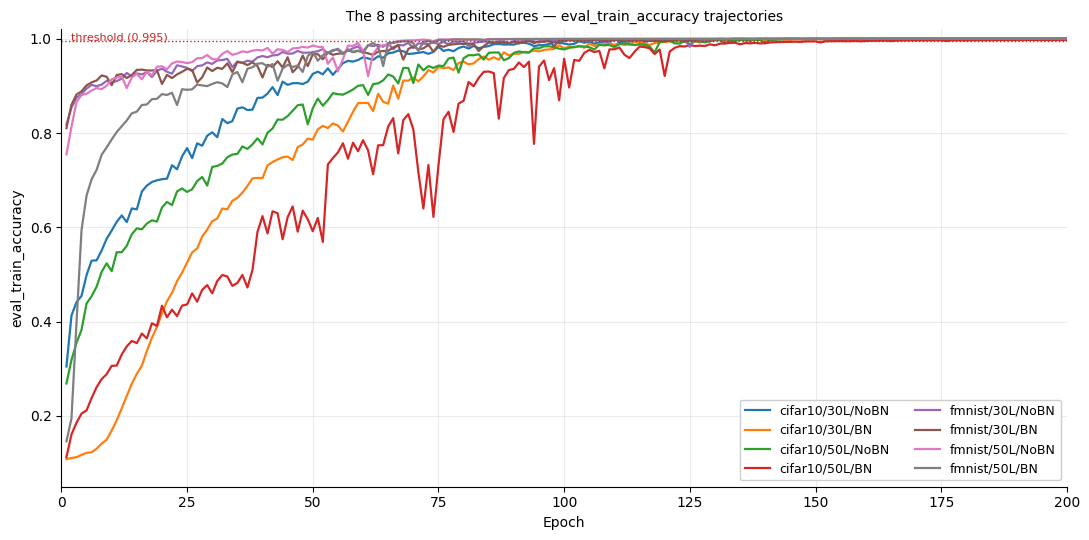

In [6]:
pass_labels = [m[0] for m in META if passes(by_label[m[0]])]

fig, ax = plt.subplots(figsize=(11, 5.5))
for label in pass_labels:
    r = by_label[label]
    m = next(mm for mm in META if mm[0] == label)
    pretty = f"{m[1]}/{m[2]}L/{'BN' if m[3] else 'NoBN'}"
    epochs = [h['epoch'] for h in r['history']]
    acc = [h.get('eval_train_accuracy', 0) for h in r['history']]
    ax.plot(epochs, acc, '-', label=pretty, linewidth=1.6)
ax.axhline(PASS_ACC, ls=':', color='#c62828', linewidth=1)
ax.text(2, 0.997, 'threshold (0.995)', fontsize=8, color='#c62828')
ax.set_xlabel('Epoch'); ax.set_ylabel('eval_train_accuracy')
ax.set_title('The 8 passing architectures — eval_train_accuracy trajectories')
ax.set_ylim(0.05, 1.02); ax.set_xlim(0, 200)
ax.grid(alpha=0.25)
ax.legend(fontsize=9, loc='lower right', ncol=2, framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_passing_overlay.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Figure 2 — The 4 failing 100L architectures

Same axes, just the architectures that did not meet the criterion. Each panel annotates peak ever-achieved accuracy and final accuracy. Notice that NoBN runs (red, top-left and bottom-left) are flat at 0.10 throughout — the model never learned anything. BN runs (blue) make tiny exploratory excursions but never get close to threshold. The fmnist/100L/BN case is the most interesting partial-failure: it reaches 0.38 and shows real loss decrease (see Figure 5).

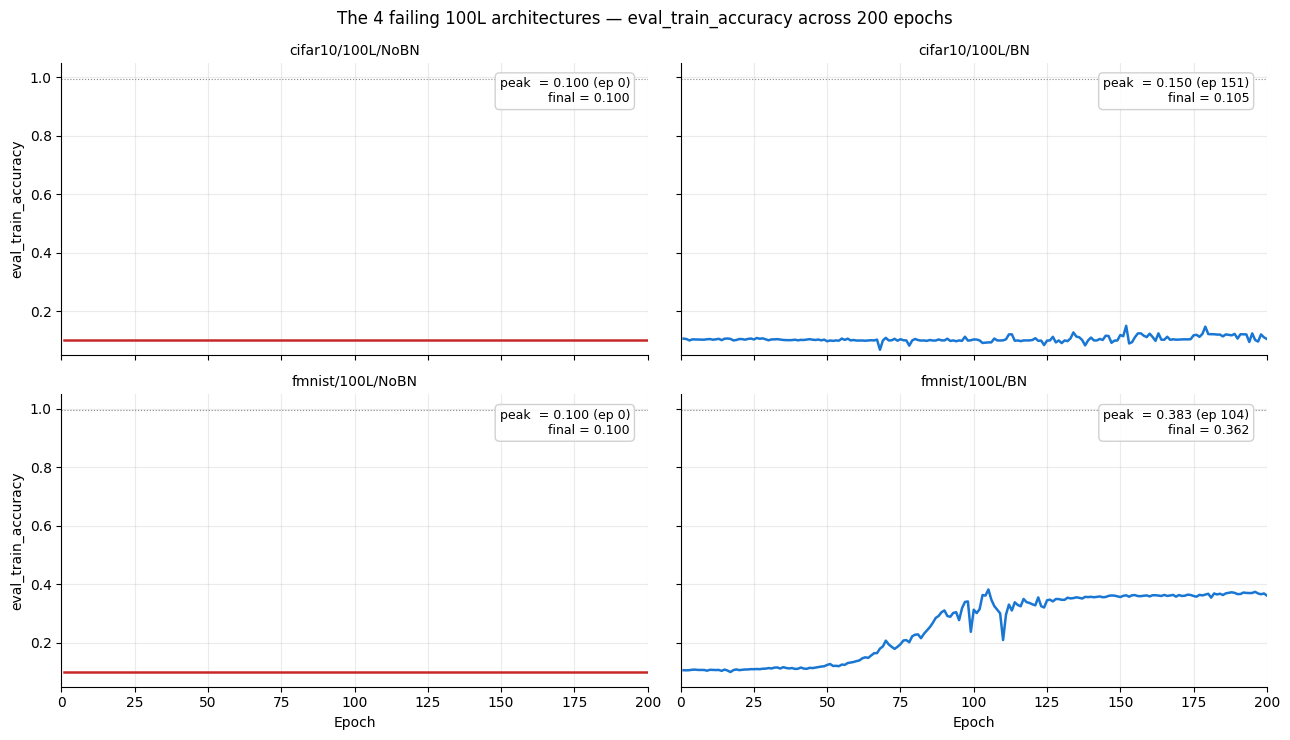

In [7]:
FAIL = [
    ('05_cifar10_100L_nobn', 'cifar10/100L/NoBN'),
    ('06_cifar10_100L_bn',   'cifar10/100L/BN'),
    ('11_fmnist_100L_nobn',  'fmnist/100L/NoBN'),
    ('12_fmnist_100L_bn',    'fmnist/100L/BN'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=True, sharey=True)
flat_axes = axes.flatten()

for (label, pretty), ax in zip(FAIL, flat_axes):
    r = by_label[label]
    epochs = [h['epoch'] for h in r['history']]
    accs = [h.get('eval_train_accuracy', 0) for h in r['history']]
    is_nobn = 'NoBN' in pretty
    color = '#c62828' if is_nobn else '#1976d2'
    ax.plot(epochs, accs, '-', color=color, linewidth=1.8)
    ax.axhline(PASS_ACC, ls=':', color='#888', linewidth=0.8)
    ax.set_ylim(0.05, 1.05)
    ax.set_xlim(0, 200)
    ax.grid(alpha=0.25)
    ax.set_title(pretty)

    peak = max(accs); peak_ep = accs.index(peak); final = accs[-1]
    ax.text(0.97, 0.95, f'peak  = {peak:.3f} (ep {peak_ep})\nfinal = {final:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.9, edgecolor='#ccc'))

for ax in axes[:, 0]:
    ax.set_ylabel('eval_train_accuracy')
for ax in axes[-1, :]:
    ax.set_xlabel('Epoch')

fig.suptitle('The 4 failing 100L architectures — eval_train_accuracy across 200 epochs', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_failing_100L_grid.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Figure 3 — LR schedules for the 8 passing runs (log scale)

Stepwise drops are `ReduceLROnPlateau` triggering after 5 epochs of no `eval_train_loss` improvement. The original 30L runs (OneCycle / cosine) have smooth decay.

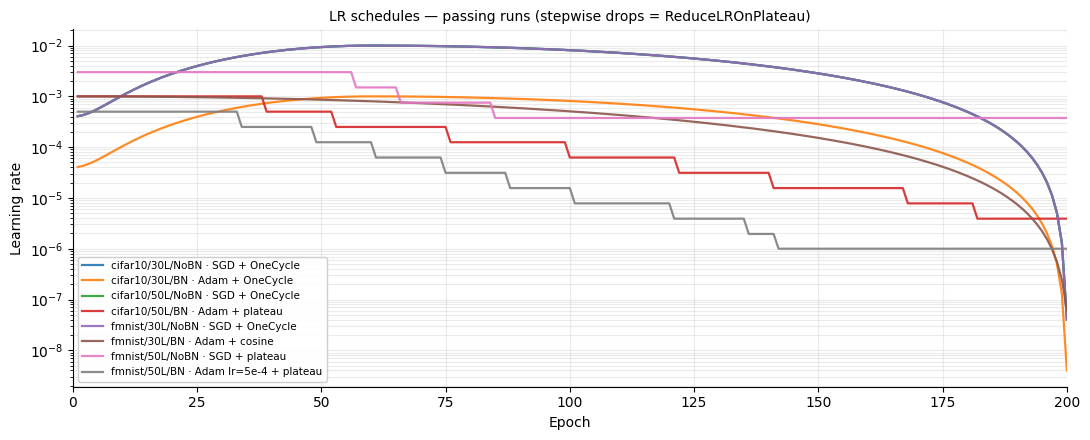

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for label in pass_labels:
    r = by_label[label]
    m = next(mm for mm in META if mm[0] == label)
    pretty = f"{m[1]}/{m[2]}L/{'BN' if m[3] else 'NoBN'} · {m[4]}"
    epochs = [h['epoch'] for h in r['history']]
    lrs = [(h.get('learning_rate') or 1e-9) for h in r['history']]
    ax.plot(epochs, lrs, '-', label=pretty, linewidth=1.6, alpha=0.9)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate'); ax.set_yscale('log')
ax.set_title('LR schedules — passing runs (stepwise drops = ReduceLROnPlateau)')
ax.grid(alpha=0.25, which='both')
ax.set_xlim(0, 200)
ax.legend(fontsize=7.5, loc='lower left', framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_lr_schedules.png', dpi=130, bbox_inches='tight')
plt.show()

## 10. Figure 4 — Generalization gap (train − test) for the 8 passing runs, BN vs NoBN

For the 8 architectures that meet the criterion, we compare how much each one over-fits to the training set: `gap = eval_train_acc − test_acc`. Smaller gap = better generalization. Grouping by BN status lets us check whether BatchNorm provides a regularization benefit at fixed dataset and depth.

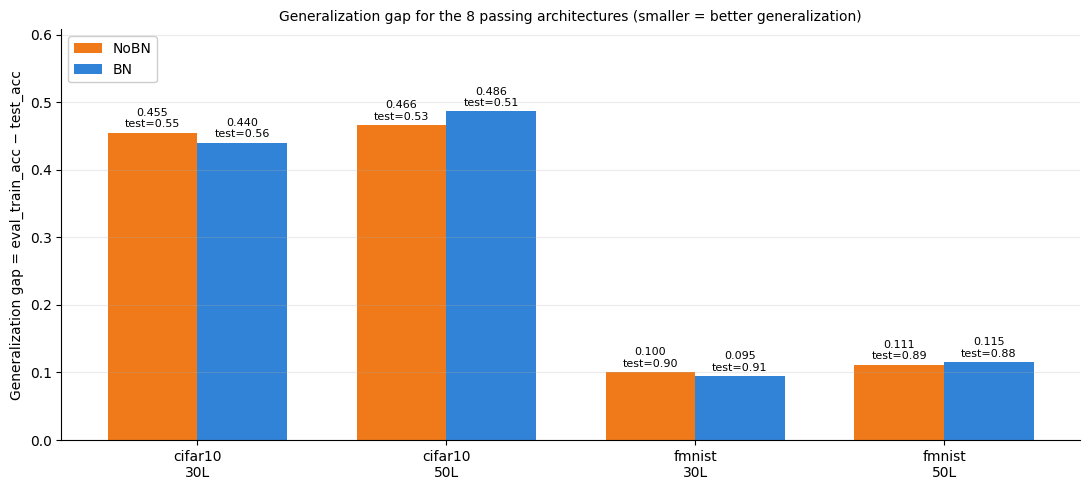

In [9]:
pass_meta = [m for m in META if passes(by_label[m[0]])]
archs = sorted({(m[1], m[2]) for m in pass_meta})

fig, ax = plt.subplots(figsize=(11, 5.0))
bar_w = 0.36
xs = np.arange(len(archs))
gap_nobn, gap_bn = [], []
test_nobn, test_bn = [], []

for ds, depth in archs:
    for bn, gap_list, test_list in [(False, gap_nobn, test_nobn), (True, gap_bn, test_bn)]:
        m = next((mm for mm in pass_meta if mm[1] == ds and mm[2] == depth and mm[3] == bn), None)
        if m is None:
            gap_list.append(np.nan); test_list.append(np.nan); continue
        h = by_label[m[0]]['history'][-1]
        train = h.get('eval_train_accuracy', 0) or 0
        test = h.get('test_accuracy', 0) or 0
        gap_list.append(train - test)
        test_list.append(test)

bars1 = ax.bar(xs - bar_w/2, gap_nobn, bar_w, color='#ef6c00', alpha=0.9, label='NoBN')
bars2 = ax.bar(xs + bar_w/2, gap_bn, bar_w, color='#1976d2', alpha=0.9, label='BN')

for bars, gaps, tests in [(bars1, gap_nobn, test_nobn), (bars2, gap_bn, test_bn)]:
    for bar, g, t in zip(bars, gaps, tests):
        if not np.isnan(g):
            ax.text(bar.get_x() + bar.get_width() / 2, g + 0.005,
                    f'{g:.3f}\ntest={t:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(xs)
ax.set_xticklabels([f'{ds}\n{depth}L' for ds, depth in archs], fontsize=10)
ax.set_ylabel('Generalization gap = eval_train_acc − test_acc')
ax.set_title('Generalization gap for the 8 passing architectures (smaller = better generalization)')
ax.set_ylim(0, max(max(gap_nobn), max(gap_bn)) * 1.25)
ax.grid(alpha=0.25, axis='y')
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_generalization_gap.png', dpi=130, bbox_inches='tight')
plt.show()

---

# Part 2 — 100L deep dive (meeting topic)

The four 100L architectures (`{cifar10, fmnist} × {NoBN, BN}`) all fail the criterion. **This is the topic of the meeting.** This section provides the most-detailed diagnostic data we have on them.

We measure six things across the 200-epoch audit run:

1. **Loss and accuracy trajectories** (Section 12 / Figure 5) — does the model do anything at all? Is loss dropping even when accuracy doesn't?
2. **Gradient health: min norm + max/min ratio** (Section 13 / Figure 6) — are gradients alive (BN) or dead (NoBN)? If alive, how conditioned are they?
3. **Per-layer gradient profile across depth** (Section 14 / Figure 7) — for the BN runs, which layers have the small gradients? Input or output?
4. **LR trajectory** (Section 15 / Figure 8) — what learning rates did the scheduler actually reach? Did plateau's adaptivity buy us anything?
5. **Diagnostic summary table** (Section 16) — single-page summary: peak acc, when, min LR reached, gradient-death epoch (NoBN), gradient ratio at termination (BN).

The wrap-up (Section 17) collects the questions to bring to the meeting.

## 12. Figure 5 — Loss and accuracy trajectories for the 4 failing 100L runs

For each of the four 100L architectures, we show the full 200-epoch trajectory of `eval_train_accuracy` (left axis, blue) and `eval_train_loss` (right axis, red). This is the "symptom" view: what does each failure mode actually look like?

**The interpretive trick.** Cross-entropy loss on 10 classes has a natural reference point: `log(10) ≈ 2.3026` is the loss of a model that outputs the uniform `1/10` distribution. So:

| Loss | Acc | What it means |
|---|---|---|
| > 2.30 | 0.10 | Model makes *confident wrong* predictions |
| ≈ 2.30 | 0.10 | Model has collapsed to *uniform output* — has "learned to be uncertain", but still hasn't learned the task |
| < 2.30 | > 0.10 | Real learning |

Reading the four panels:

- **cifar10/100L/NoBN:** loss pinned at exactly 2.3026 throughout, acc at 0.10. **Dead from epoch 1** — gradients zero, parameters never update.
- **cifar10/100L/BN:** loss drops 3.83 → **2.31** (still right at uniform-output baseline), acc stays at 0.10. The model *did* update — it moved from "confidently wrong" to "uniform output" — but it did not actually learn to classify. This is the subtle case: loss *is* decreasing, which would normally signal learning, but it's just collapsing to maximum-uncertainty.
- **fmnist/100L/NoBN:** loss pinned at 2.3026, acc at 0.10. Dead.
- **fmnist/100L/BN:** loss drops to **1.66** (well below 2.30), acc reaches **0.38**. **Real learning is happening here** — the only one of the four. Still nowhere near the 0.995 threshold, but mechanistically different from the other three.

This is a strong way to frame it for the meeting: three of the four 100L runs are mechanistically dead (in two different ways), and only one — fmnist/100L/BN — actually trains, just not enough.

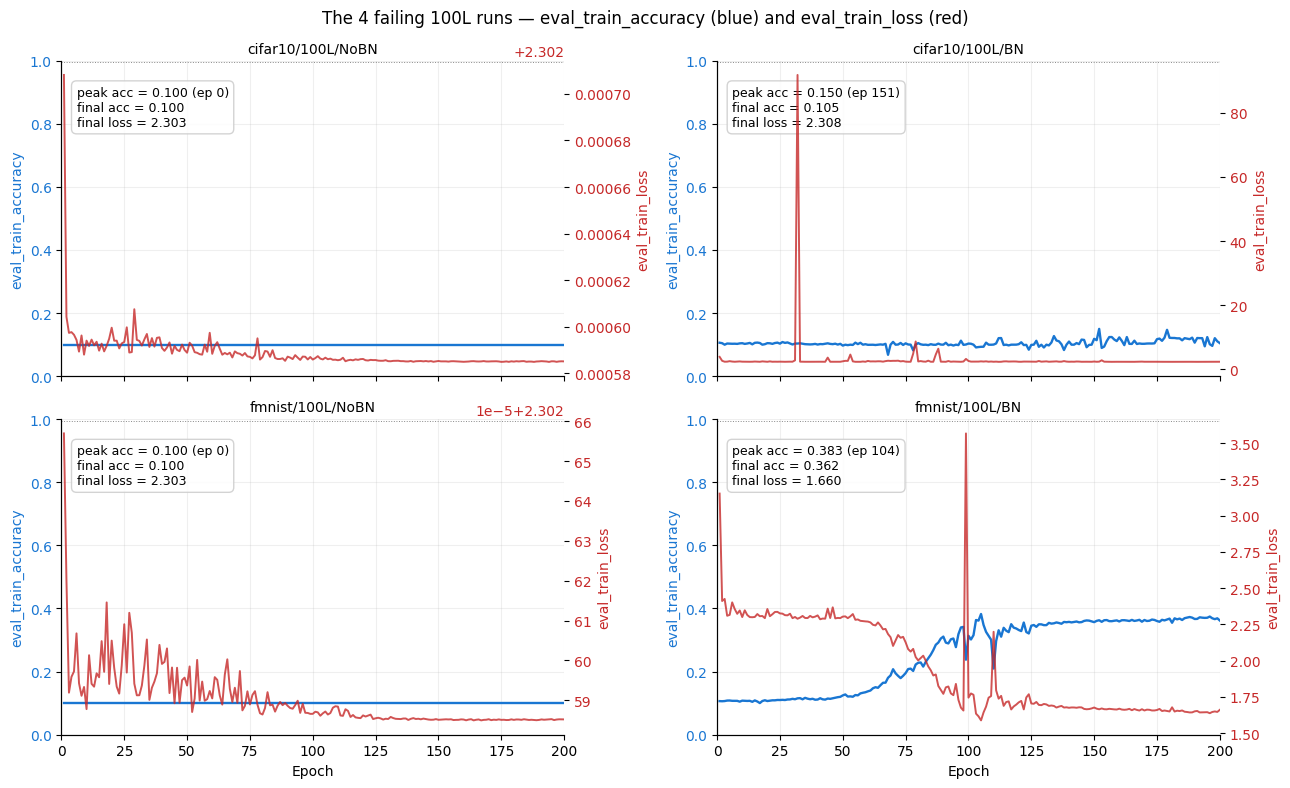

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

PANELS = [
    ('05_cifar10_100L_nobn', 'cifar10/100L/NoBN', axes[0, 0]),
    ('06_cifar10_100L_bn',   'cifar10/100L/BN',   axes[0, 1]),
    ('11_fmnist_100L_nobn',  'fmnist/100L/NoBN',  axes[1, 0]),
    ('12_fmnist_100L_bn',    'fmnist/100L/BN',    axes[1, 1]),
]

for label, pretty, ax in PANELS:
    r = by_label[label]
    epochs = [h['epoch'] for h in r['history']]
    accs = [h.get('eval_train_accuracy', 0) for h in r['history']]
    losses = [h.get('eval_train_loss', 0) for h in r['history']]

    # Left axis: accuracy
    ax.plot(epochs, accs, '-', color='#1976d2', linewidth=1.7, label='eval_train_acc')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('eval_train_accuracy', color='#1976d2')
    ax.tick_params(axis='y', labelcolor='#1976d2')
    ax.axhline(PASS_ACC, ls=':', color='#888', linewidth=0.7)

    # Right axis: loss
    ax2 = ax.twinx()
    ax2.plot(epochs, losses, '-', color='#c62828', linewidth=1.4, alpha=0.8, label='eval_train_loss')
    ax2.set_ylabel('eval_train_loss', color='#c62828')
    ax2.tick_params(axis='y', labelcolor='#c62828')
    ax2.spines['top'].set_visible(False)

    # Annotations: peak acc and final state
    peak = max(accs); peak_ep = accs.index(peak)
    ax.text(0.03, 0.92, f'peak acc = {peak:.3f} (ep {peak_ep})\n'
                       f'final acc = {accs[-1]:.3f}\n'
                       f'final loss = {losses[-1]:.3f}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#ccc'))
    ax.set_title(pretty)
    ax.set_xlim(0, 200)
    ax.grid(alpha=0.2)

for ax in axes[1, :]:
    ax.set_xlabel('Epoch')

fig.suptitle('The 4 failing 100L runs — eval_train_accuracy (blue) and eval_train_loss (red)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_100L_loss_acc.png', dpi=130, bbox_inches='tight')
plt.show()

## 13. Figure 6 — Gradient health for the 4 100L runs

Two panels:
- **Left:** per-layer **minimum** gradient norm across epochs (log scale). The NoBN runs (red, orange) are pinned to machine-zero from the very first diagnostic checkpoint — that is the gradient-death pathology. The BN runs (blue, purple) stay safely above 1e-2 throughout.
- **Right:** per-layer gradient max/min **ratio** (log scale). Only defined for the BN runs (NoBN ratio is `0/0 = undefined` once the gradients die). The BN runs sit at 10⁵–10⁷ throughout, which is why no global LR can serve all layers.

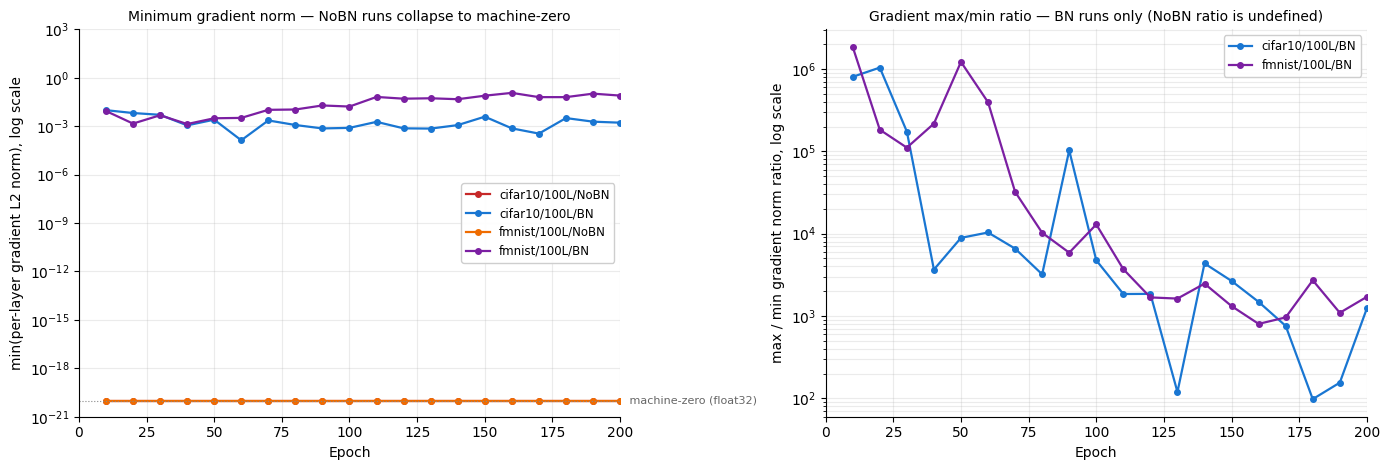

In [11]:
fig, (ax_min, ax_ratio) = plt.subplots(1, 2, figsize=(14, 4.8))

N100 = [
    ('05_cifar10_100L_nobn', '#c62828', 'cifar10/100L/NoBN'),
    ('06_cifar10_100L_bn',   '#1976d2', 'cifar10/100L/BN'),
    ('11_fmnist_100L_nobn',  '#ef6c00', 'fmnist/100L/NoBN'),
    ('12_fmnist_100L_bn',    '#7b1fa2', 'fmnist/100L/BN'),
]

FLOOR = 1e-20  # representation for "machine-zero" on a log axis

# --- Left panel: minimum per-layer gradient norm ---
for label, color, pretty in N100:
    r = by_label[label]
    epochs, mins = [], []
    for h in r['history']:
        gnpl = h.get('grad_norm_per_layer')
        if gnpl:
            epochs.append(h['epoch'])
            mn = min(gnpl)
            mins.append(mn if mn > 0 else FLOOR)
    if epochs:
        ax_min.plot(epochs, mins, 'o-', color=color, label=pretty, linewidth=1.6, markersize=4)

ax_min.axhline(FLOOR, ls=':', color='#888', linewidth=0.8)
ax_min.text(202, FLOOR, ' machine-zero (float32)', fontsize=8, color='#666', va='center')
ax_min.set_xlabel('Epoch')
ax_min.set_ylabel('min(per-layer gradient L2 norm), log scale')
ax_min.set_yscale('log')
ax_min.set_ylim(FLOOR * 0.1, 1e3)
ax_min.set_title('Minimum gradient norm — NoBN runs collapse to machine-zero')
ax_min.set_xlim(0, 200)
ax_min.grid(alpha=0.25, which='both')
ax_min.legend(fontsize=8.5, loc='center right', framealpha=0.95)

# --- Right panel: max/min ratio (BN only) ---
for label, color, pretty in N100:
    r = by_label[label]
    epochs, ratios = [], []
    for h in r['history']:
        gnpl = h.get('grad_norm_per_layer')
        if gnpl:
            mn = min(gnpl); mx = max(gnpl)
            if mn > 0 and mx > 0:
                epochs.append(h['epoch'])
                ratios.append(mx / mn)
    if ratios:
        ax_ratio.plot(epochs, ratios, 'o-', color=color, label=pretty, linewidth=1.6, markersize=4)

ax_ratio.set_xlabel('Epoch')
ax_ratio.set_ylabel('max / min gradient norm ratio, log scale')
ax_ratio.set_yscale('log')
ax_ratio.set_title('Gradient max/min ratio — BN runs only (NoBN ratio is undefined)')
ax_ratio.set_xlim(0, 200)
ax_ratio.grid(alpha=0.25, which='both')
ax_ratio.legend(fontsize=8.5, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_100L_gradient_ratios.png', dpi=130, bbox_inches='tight')
plt.show()

## 14. Figure 7 — Per-layer gradient profile across depth (BN runs only)

For the two 100L/BN runs (the only ones with non-zero gradients to plot), we show the per-layer gradient L2 norm as a function of layer index (0 = first hidden, 99 = output). Each colored line is one diagnostic snapshot epoch.

*Note on dimensions:* the network has **depth = 100** (100 stacked hidden FC layers, so 100 points on the x-axis) and **width = 500** (each layer is a 500×500 weight matrix). The x-axis is the *layer index*, not the *neuron index*.

**Interpretation.** Both runs show a strong **exponential decay across depth** at every epoch — early layers have gradient norms in the 10² to 10⁴ range; deep layers (60–99) sit at 10⁻² or below. The ratio between best- and worst-conditioned layer is precisely what the right panel of Figure 6 already summarized: 10⁵ to 10⁷, far outside any "well-conditioned" regime.

**Does conditioning improve over training?** *Partially.* Looking at cifar10/100L/BN: layer 0's gradient norm calms down by ~4 orders of magnitude (7,893 at ep 10 → 2.0 at ep 200), while deep-layer norms barely move (0.024 → 0.036). So the conditioning *did* improve over time — the worst-case ratio shrinks from ~10⁶ at ep 10 toward 10³ by ep 200 — but **even after 200 epochs of contraction it never gets good enough to actually train.** The model is asymptotically approaching a still-pathological state.

This is the most precise diagnosis of the 100L/BN failure: BatchNorm rescues the gradients from machine-zero, and training does slowly improve conditioning, but the rate of improvement is too slow relative to the depth-induced scale spread.

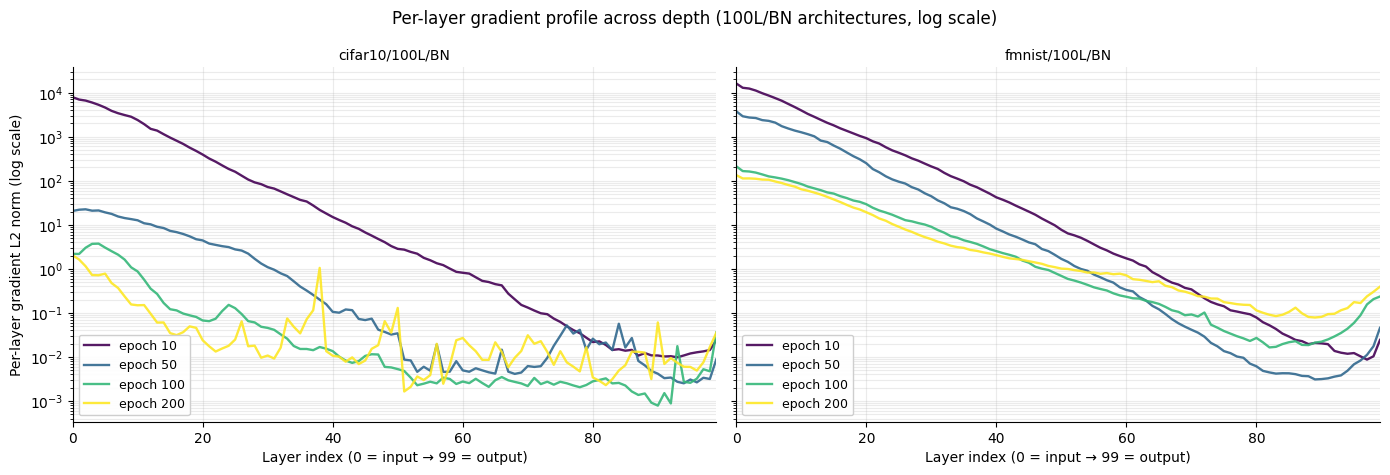


Architecture                ep    layer 0   layer 25   layer 50   layer 75   layer 99
cifar10/100L/BN             10   7.89e+03   1.60e+02   2.84e+00   6.24e-02   2.41e-02
cifar10/100L/BN            200   2.04e+00   2.48e-02   1.30e-01   1.35e-02   3.56e-02
fmnist/100L/BN              10   1.61e+04   4.31e+02   7.69e+00   1.42e-01   2.44e-02
fmnist/100L/BN             200   1.34e+02   9.02e+00   1.01e+00   1.75e-01   3.94e-01


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

BN_RUNS = [
    ('06_cifar10_100L_bn', 'cifar10/100L/BN', axes[0]),
    ('12_fmnist_100L_bn',  'fmnist/100L/BN',  axes[1]),
]
EPOCHS_TO_PLOT = [10, 50, 100, 200]
CMAP = plt.cm.viridis

for label, pretty, ax in BN_RUNS:
    r = by_label[label]
    snapshots = {}
    for h in r['history']:
        if h['epoch'] in EPOCHS_TO_PLOT and h.get('grad_norm_per_layer'):
            snapshots[h['epoch']] = h['grad_norm_per_layer']
    for i, ep in enumerate(sorted(snapshots.keys())):
        gnpl = snapshots[ep]
        color = CMAP(i / max(1, len(EPOCHS_TO_PLOT) - 1))
        ax.plot(range(len(gnpl)), gnpl, '-', color=color, label=f'epoch {ep}', linewidth=1.7, alpha=0.9)
    ax.set_yscale('log')
    ax.set_xlabel('Layer index (0 = input → 99 = output)')
    if ax is axes[0]:
        ax.set_ylabel('Per-layer gradient L2 norm (log scale)')
    ax.set_title(pretty)
    ax.set_xlim(0, 99)
    ax.grid(alpha=0.25, which='both')
    ax.legend(fontsize=9, loc='lower left', framealpha=0.95)

fig.suptitle('Per-layer gradient profile across depth (100L/BN architectures, log scale)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_100L_per_layer_profile.png', dpi=130, bbox_inches='tight')
plt.show()

# Quick numerical summary
print(f'\n{"Architecture":<25} {"ep":>4} {"layer 0":>10} {"layer 25":>10} {"layer 50":>10} {"layer 75":>10} {"layer 99":>10}')
for label, pretty, _ in BN_RUNS:
    r = by_label[label]
    for h in r['history']:
        if h['epoch'] in [10, 200] and h.get('grad_norm_per_layer'):
            g = h['grad_norm_per_layer']
            print(f'{pretty:<25} {h["epoch"]:>4} {g[0]:>10.2e} {g[25]:>10.2e} {g[50]:>10.2e} {g[75]:>10.2e} {g[99]:>10.2e}')

## 15. Figure 8 — LR trajectories actually achieved for the 4 100L runs

Each scheduler drove LR down by 3–5 orders of magnitude across the 200 epochs. **None of these decays produced learning.** Three of the four runs use cosine (smooth decay to ~6e-8) and their trajectories overlap perfectly, which is why only **two distinct lines are visible** on the plot — the fourth (fmnist/100L/BN) uses plateau and has the visibly stepwise curve.

**Did we try plateau on the other 100L runs?** Yes — plateau was tested for all 100L/BN cases. It was chosen as the *best-known* recipe only for fmnist/100L/BN; for cifar10/100L/BN cosine actually performed slightly better.

| Architecture | Schedulers tried | Best | Why |
|---|---|---|---|
| cifar10/100L/NoBN | cosine | cosine | NoBN gradients are float32 zero → LR is irrelevant (anything × 0 = 0) |
| cifar10/100L/BN | cosine, plateau (P3 δ₁), plateau+warmup (P4 ζ₁) | **cosine** | plateau got stuck at 0.11; cosine slightly better at 0.10–0.15 |
| fmnist/100L/NoBN | cosine | cosine | Same as cifar10/NoBN — gradients dead, LR irrelevant |
| fmnist/100L/BN | cosine, plateau (P3 δ₂), plateau+warmup (P4 ζ₂) | **plateau** | plateau gave slow climb to 0.34, the best 100L result we have |

The LR axis is also a useful sanity check on the "just try a smaller LR" suggestion: LR has effectively gone to zero (~1e-6 to 1e-8) on all four runs without rescuing anything. The bottleneck is upstream of LR.

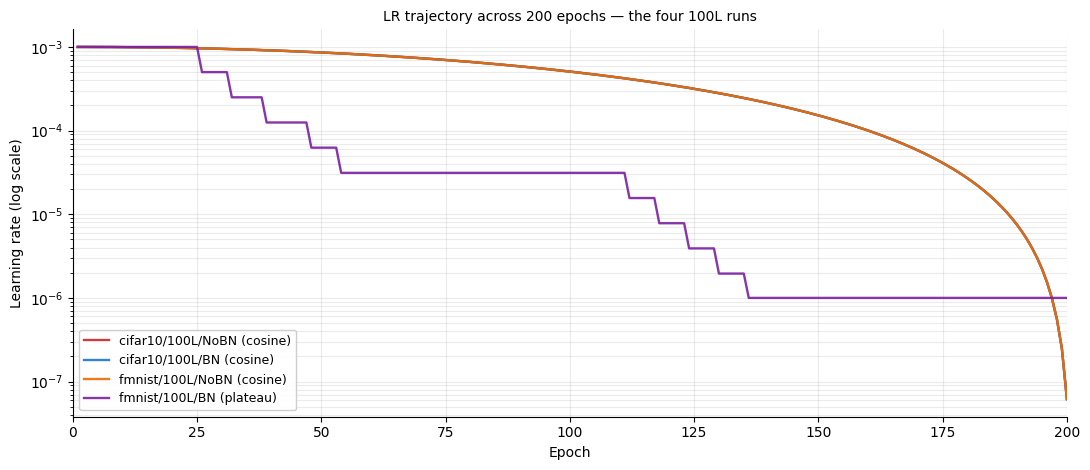

Min LR reached during training:
  cifar10/100L/NoBN          scheduler=cosine      start=1.00e-03  min=6.17e-08  final=6.17e-08
  cifar10/100L/BN            scheduler=cosine      start=1.00e-03  min=6.17e-08  final=6.17e-08
  fmnist/100L/NoBN           scheduler=cosine      start=1.00e-03  min=6.17e-08  final=6.17e-08
  fmnist/100L/BN             scheduler=plateau     start=1.00e-03  min=1.00e-06  final=1.00e-06


In [13]:
fig, ax = plt.subplots(figsize=(11, 4.8))
for label, color, pretty in N100:
    r = by_label[label]
    epochs = [h['epoch'] for h in r['history']]
    lrs = [(h.get('learning_rate') or 1e-12) for h in r['history']]
    sched = r['training_config']['scheduler']
    ax.plot(epochs, lrs, '-', color=color, label=f'{pretty} ({sched})', linewidth=1.7, alpha=0.9)

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate (log scale)')
ax.set_yscale('log')
ax.set_title('LR trajectory across 200 epochs — the four 100L runs')
ax.set_xlim(0, 200)
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=9, loc='lower left', framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_100L_lr_trajectories.png', dpi=130, bbox_inches='tight')
plt.show()

print('Min LR reached during training:')
for label, _, pretty in N100:
    r = by_label[label]
    lrs = [h.get('learning_rate') or float('nan') for h in r['history']]
    print(f'  {pretty:25s}  scheduler={r["training_config"]["scheduler"]:10s}  '
          f'start={lrs[0]:.2e}  min={min(lrs):.2e}  final={lrs[-1]:.2e}')

## 16. 100L diagnostic summary table

Compact numbers per 100L architecture: peak ever-achieved accuracy and the epoch it occurred, final accuracy/loss, the LR range actually traversed (start → min → final), the number of scheduler-triggered LR drops, the first epoch at which all per-layer gradients are float32 zero (NoBN marker), and the final max/min gradient ratio (BN marker). This is the most data-dense summary of the 100L state.

In [14]:
rows = []
for label, _, pretty in N100:
    r = by_label[label]
    h = r['history']
    sched = r['training_config']['scheduler']
    accs = [hh.get('eval_train_accuracy', 0) or 0 for hh in h]
    losses = [hh.get('eval_train_loss', 0) or 0 for hh in h]
    lrs = [hh.get('learning_rate') or float('nan') for hh in h]

    peak_acc = max(accs); peak_ep = accs.index(peak_acc)
    final_acc = accs[-1]; final_loss = losses[-1]
    min_loss = min(losses)
    start_lr = lrs[0]; min_lr = min(lrs); final_lr = lrs[-1]

    # Count DISCRETE step-events only: LR ratio ≤ 0.7 in a single epoch.
    # This captures plateau halvings (ratio = 0.5) but ignores cosine's smooth per-epoch decay.
    discrete_drops = sum(1 for i in range(1, len(lrs)) if lrs[i] <= lrs[i-1] * 0.7)

    # First epoch at which all per-layer gradients are exactly zero (NoBN failure marker)
    first_zero_ep = None
    for hh in h:
        gnpl = hh.get('grad_norm_per_layer')
        if gnpl and max(gnpl) == 0.0:
            first_zero_ep = hh['epoch']; break

    # Max/min gradient ratio at the last available diagnostic snapshot (BN runs only)
    last_ratio = None
    for hh in reversed(h):
        gnpl = hh.get('grad_norm_per_layer')
        if gnpl and min(gnpl) > 0:
            last_ratio = max(gnpl) / min(gnpl); break

    rows.append({
        'arch': pretty, 'sched': sched,
        'peak_acc': peak_acc, 'peak_ep': peak_ep,
        'final_acc': final_acc, 'min_loss': min_loss, 'final_loss': final_loss,
        'start_lr': start_lr, 'min_lr': min_lr, 'final_lr': final_lr,
        'discrete_drops': discrete_drops,
        'first_zero_ep': first_zero_ep, 'last_ratio': last_ratio,
    })

print(f"{'Architecture':<22} {'peak_acc':>9} {'peak_ep':>8} {'final_acc':>10} {'min_loss':>9} {'final_loss':>11}")
print('-' * 80)
for r in rows:
    print(f"{r['arch']:<22} {r['peak_acc']:>9.4f} {r['peak_ep']:>8d} {r['final_acc']:>10.4f} {r['min_loss']:>9.4f} {r['final_loss']:>11.4f}")

print()
print(f"{'Architecture':<22} {'sched':<8} {'start_lr':>10} {'min_lr':>10} {'final_lr':>10} {'step_drops':>11} {'grad_first_zero':>17} {'final ratio':>14}")
print('-' * 110)
for r in rows:
    fz = 'n/a' if r['first_zero_ep'] is None else f"ep {r['first_zero_ep']}"
    rt = 'undef' if r['last_ratio'] is None else f"{r['last_ratio']:.2e}"
    print(f"{r['arch']:<22} {r['sched']:<8} {r['start_lr']:>10.2e} {r['min_lr']:>10.2e} {r['final_lr']:>10.2e} {r['discrete_drops']:>11d} {fz:>17} {rt:>14}")

print()
print('Column notes:')
print('  step_drops    = number of *discrete* LR step events (≥30% drop in a single epoch).')
print('                  Plateau halvings (×0.5) count here; cosine smooth decay does NOT.')
print('  grad_first_zero = first epoch at which ALL 100 per-layer gradients are float32 zero.')
print('                    "ep 10" = the earliest diagnostic checkpoint we logged, so this is')
print('                    really "≤ ep 10" — gradients had already died by then.')
print('  final ratio   = max/min per-layer gradient norm at the last diagnostic snapshot.')
print('                  Undefined for NoBN (0/0); 10^5–10^7 for BN runs.')

Architecture            peak_acc  peak_ep  final_acc  min_loss  final_loss
--------------------------------------------------------------------------------
cifar10/100L/NoBN         0.1000        0     0.1000    2.3026      2.3026
cifar10/100L/BN           0.1500      151     0.1049    2.2627      2.3078
fmnist/100L/NoBN          0.1000        0     0.1000    2.3026      2.3026
fmnist/100L/BN            0.3825      104     0.3618    1.5879      1.6605

Architecture           sched      start_lr     min_lr   final_lr  step_drops   grad_first_zero    final ratio
--------------------------------------------------------------------------------------------------------------
cifar10/100L/NoBN      cosine     1.00e-03   6.17e-08   6.17e-08           5             ep 10          undef
cifar10/100L/BN        cosine     1.00e-03   6.17e-08   6.17e-08           5               n/a       1.24e+03
fmnist/100L/NoBN       cosine     1.00e-03   6.17e-08   6.17e-08           5             ep 10        

## 17. Wrap-up — questions to bring to the meeting

The audit confirms 8 / 12 architectures pass; the four 100L architectures do not. From the deep-dive section above we can already say:

- **100L/NoBN** (red/orange in Figure 6 left): gradients underflow to exactly zero across all 100 layers by the first diagnostic checkpoint (ep 10). Loss never moves. No LR schedule rescues a zero gradient. This is a forward-signal pathology of He init at extreme depth — the fix would be different init (Fixup, ZerO, DeepNorm) or different architecture (residual blocks, LayerNorm).

- **100L/BN** (blue/purple): gradients survive but per-layer scale spans 10⁵–10⁷ (Figure 6 right, Figure 7). Plateau and cosine both drive LR down to 1e-7–1e-8 without breakthrough (Figure 8). This is a *conditioning* problem, not an LR problem. The most thesis-adjacent next experiment is **LARS or Lamb** (layer-wise adaptive optimizers), which would keep He init + BN and only swap the optimizer.

**Open questions for the meeting:**
1. Is the current result the natural stopping point to write up, or worth pursuing a layer-adaptive optimizer experiment for the 100L/BN cases?
2. For the 100L/NoBN gradient-death observation: do you want it framed as a "He init at depth 100 is mathematically untrainable without normalization" result, or do you want one more attempt (e.g. LayerNorm, or `bn_momentum` very small with effectively-BN-disabled normalization layers)?
3. fmnist/100L/BN does *learn* something (0.36 accuracy is well above chance, loss drops to 1.66) while cifar10/100L/BN does not. Is this dataset-asymmetry result worth a separate discussion?

Every figure above is saved to `reports/figures/final_*.png` and the audit is re-runnable from `cluster/run_final.py`.